In [1]:
from langchain_groq import ChatGroq
from langchain.agents.factory import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client
import streamlit as st
import os
from langchain_mcp_adapters.tools import load_mcp_tools
from IPython.display import Markdown, display
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, Markdown, display


/Users/sushovansaha/Desktop/Project/Personal/Streamlit-AI-Portfolio/.port/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from typing import Dict,Annotated,List
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from langchain_core.messages import SystemMessage, HumanMessage


class ArticleResponse(TypedDict):
    topic: str
    summary: str
    knowledge: Annotated[list[AnyMessage], add_messages]
    
   

In [3]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [4]:
model_name = "moonshotai/kimi-k2-instruct" #"moonshotai/kimi-k2-instruct" "qwen/qwen3-32b"
temperature = 0.0


llm = ChatGroq(
    model_name=model_name,
    temperature=temperature
)   


In [7]:
from langgraph.prebuilt import create_react_agent


In [8]:
async def airbnbAgent(state):
    
    server_params = StdioServerParameters(
            command= "npx",
            args= [
                "-y",
                "@openbnb/mcp-server-airbnb",
                "--ignore-robots-txt"
            ],
        )
    
    
    async with stdio_client(server_params) as (read, write):
            async with ClientSession(read, write) as session:
                print("Initializing connection...")
                await session.initialize()

                # Get tools
                print("Loading tools...")
                tools = await load_mcp_tools(session)
                
                
                agent = create_react_agent(
                    model=llm,
                    tools=tools,
                    prompt = (
                        """
                        **ADVANCED HOTEL SEARCH FORMAT**

                        ## 🎯 Search Summary
                        - **Location:** [location] | **Dates:** [checkin] → [checkout]
                        - **Guests:** [adults]A, [children]C, [infants]I, [pets]P
                        - **Room:** [room type] | **Stars:** [rating] | **Amenities:** [amenities]
                        - **Results:** [number] hotels

                        ## 🏨 Hotel Listings
                        ### [Hotel Name]
                        | Detail | Info |
                        |--------|------|
                        | ⭐ Rating | [rating]/5 ([reviews]) |
                        | 📍 Address | [full address] |
                        | 💰 Rate | $[price]/night (+$[tax]) |
                        | 🏠 Rooms | [categories] |
                        | 📏 Distance | [city center] • [airport] |
                        | 🔗 Booking | [URL] |
                        | 📞 Contact | [phone] • [website] |

                        **Amenities:** [pool/gym/spa, dining, transport, business, pets, WiFi, services]  
                        **Booking:** Check-in [time], Check-out [time], Cancellation [policy], Payment [methods], Breakfast [info], Parking [info], Extra Beds [policy]

                        **Match Analysis:** Budget [fit], Amenities [X/Y matched], Location [score], Guest Reviews [highlights]  
                        **Recommendations:** Best for [use case], Offers [promos], Tips [advice]

                        -- repeat per hotel --

                        ## 📈 Comparison
                        | Hotel | Rating | Price | Features | Link |
                        |-------|--------|-------|----------|------|
                        | [H1] | [rating]⭐ | $[price] | [2 highlights] | [URL] |
                        | [H2] | [rating]⭐ | $[price] | [2 highlights] | [URL] |

                        ## 🏆 Final Picks
                        - **Best Value:** [hotel + reason]
                        - **Luxury:** [hotel + features]
                        - **Budget:** [hotel + savings]
                        - **Location:** [hotel + benefit]
                        - **Amenities:** [hotel + standout]
                        """
                    )
                )
            
                response = await agent.ainvoke({"messages": [{"role": "user", "content": state['topic']}]})

                ai_content = response["messages"][-1].content

                return {"knowledge": [f"[Info from AirBnb Search]\n{ai_content}\n\n"]}
                

In [9]:
res = await airbnbAgent({"topic": "Find me the top 5 Airbnb in Darjeeling for next 3 days within 8000 for 2 people?"})

Initializing connection...
Loading tools...


/var/folders/xt/q4j7gg3n3z3fx6rz7xq8hxfc0000gn/T/ipykernel_36704/3637644559.py:23: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [10]:
display(Markdown(f"# 📝 Report\n\n{res['knowledge']}"))

# 📝 Report

['[Info from AirBnb Search]\nBased on my search, I found several excellent Airbnb options in Darjeeling for your 3-day stay within your ₹8000 budget for 2 people. Here are the top 5 recommendations:\n\n## 🏆 Top 5 Airbnb Properties in Darjeeling (Dec 20-23, 2024)\n\n### 1. **The Little Paradise Kalimpong - Jasmine** ⭐\n- **Rating:** 5.0/5 (24 reviews)\n- **Price:** ₹2,453/night (₹7,359 for 3 nights)\n- **Location:** Kalimpong area\n- **Features:** Guest favourite, 1 bed\n- **Link:** [View Property](https://www.airbnb.com/rooms/708311291872481455)\n\n### 2. **Michewa Cottage** ⭐\n- **Rating:** 5.0/5 (11 reviews)\n- **Price:** ₹1,826/night (₹5,478 for 3 nights)\n- **Location:** Near Darjeeling\n- **Features:** Guest favourite, 2 bedrooms, 2 double beds\n- **Link:** [View Property](https://www.airbnb.com/rooms/905032389080151646)\n\n### 3. **Eco-friendly Retreat** ⭐\n- **Rating:** 4.97/5 (35 reviews)\n- **Price:** ₹1,609/night (₹4,827 for 3 nights)\n- **Location:** Darjeeling area\n- **Features:** Guest favourite, 2 bedrooms, 2 double beds\n- **Link:** [View Property](https://www.airbnb.com/rooms/46013589)\n\n### 4. **Farm Find** ⭐\n- **Rating:** 4.88/5 (26 reviews)\n- **Price:** ₹1,927/night (₹5,781 for 3 nights)\n- **Location:** Darjeeling area\n- **Features:** Guest favourite, 3 bedrooms, 6 beds\n- **Link:** [View Property](https://www.airbnb.com/rooms/905616065133200482)\n\n### 5. **Cozy Cottage / Budget-friendly**\n- **Price:** ₹913/night (₹2,739 for 3 nights after discount)\n- **Location:** Darjeeling area\n- **Features:** 3 bedrooms, 3 beds, Special discount available\n- **Link:** [View Property](https://www.airbnb.com/rooms/1653480072042963459)\n\n## 💡 Recommendations:\n\n**Best Value:** **Cozy Cottage** - Only ₹913/night with special discounts\n**Most Luxurious:** **The Little Paradise** - Premium amenities with perfect rating\n**Best for Groups:** **Michewa Cottage** - 2 bedrooms, perfect for couples or friends\n\nAll properties are well within your ₹8000 budget for 3 nights, leaving you with extra money for activities and dining. The prices shown are for your exact dates (Dec 20-23, 2024) for 2 adults.\n\nWould you like me to get more detailed information about any specific property, including amenities, exact location, and availability?\n\n']

In [11]:
import requests
import json
import os

In [12]:
def extract_weather(data: dict) -> str:
    """
    Extracts location, current weather, and 3-day forecast info from WeatherAPI JSON.
    Returns as a formatted string instead of printing.
    """
    lines = []

    # --- Location info ---
    loc = data.get("location", {})
    location = f"{loc.get('name')}, {loc.get('region')}, {loc.get('country')}"
    lines.append(f"📍 Location: {location}")

    # --- Current weather ---
    current = data.get("current", {})
    condition = current.get("condition", {}).get("text")
    temp_c = current.get("temp_c")
    feelslike_c = current.get("feelslike_c")
    humidity = current.get("humidity")
    gust_kph = current.get("gust_kph")
    pressure_mb = current.get("pressure_mb")

    lines.append("\n🌤️ Current Weather:")
    lines.append(f"  Temp: {temp_c}°C (Feels like {feelslike_c}°C)")
    lines.append(f"  Condition: {condition}")
    lines.append(f"  Humidity: {humidity}%")
    lines.append(f"  Wind Gust: {gust_kph} kph")
    lines.append(f"  Pressure: {pressure_mb} mb")

    # --- Forecast info ---
    forecast = data.get("forecast", {}).get("forecastday", [])
    lines.append("\n📅 Forecast:")
    for day in forecast:
        d = day.get("date")
        details = day.get("day", {})
        lines.append(f"  Date: {d}")
        lines.append(f"    Condition: {details.get('condition', {}).get('text')}")
        lines.append(f"    Max Temp: {details.get('maxtemp_c')}°C")
        lines.append(f"    Min Temp: {details.get('mintemp_c')}°C")
        lines.append(f"    Avg Humidity: {details.get('avghumidity')}%")
        lines.append(f"    Max Wind: {details.get('maxwind_kph')} kph")
        lines.append("-" * 40)

    return "\n".join(lines)


In [17]:
@tool("WeatherForecast")
def get_forecast(location: str, days: int = 3):
    """
    Fetch weather forecast for a given location using WeatherAPI.

    Args:
        location (str): City name or coordinates (e.g., "London" or "51.5072,-0.1276").
        days (int): Number of days to forecast (default = 3).

    Returns:
        dict: Forecast data if successful, None otherwise.
    """
    print("WeatherForecast tool")
    API_KEY = os.getenv("WEATHER_API_KEY")  # ⚠️ keep private in real apps
    
    params = {
        "key": API_KEY,
        "q": location,
        "days": days,
        "aqi": "no",
        "alerts": "yes"
    }

    BASE_URL = f"http://api.weatherapi.com/v1/forecast.json?key={params['key']}&q={params['q']}&days={params['days']}&aqi={params['aqi']}&alerts={params['alerts']}"

    try:
        response = requests.get(BASE_URL, timeout=10)
        response.raise_for_status()  # raise error for bad status
        data = response.json()
        forecast = extract_weather(data)
        return forecast
    except requests.RequestException as e:
        print(f"Error fetching forecast: {e}")
        return None

In [18]:
weather = get_forecast.invoke("Darjeeling")

WeatherForecast tool


In [19]:
print(weather)

📍 Location: Darjeeling, West Bengal, India

🌤️ Current Weather:
  Temp: 15.2°C (Feels like 15.2°C)
  Condition: Clear
  Humidity: 77%
  Wind Gust: 11.3 kph
  Pressure: 1012.0 mb

📅 Forecast:
  Date: 2026-04-11
    Condition: Patchy rain nearby
    Max Temp: 16.1°C
    Min Temp: 11.7°C
    Avg Humidity: 70%
    Max Wind: 9.7 kph
----------------------------------------
  Date: 2026-04-12
    Condition: Patchy rain nearby
    Max Temp: 18.1°C
    Min Temp: 13.9°C
    Avg Humidity: 66%
    Max Wind: 11.5 kph
----------------------------------------
  Date: 2026-04-13
    Condition: Patchy rain nearby
    Max Temp: 20.5°C
    Min Temp: 14.8°C
    Avg Humidity: 62%
    Max Wind: 11.5 kph
----------------------------------------


In [20]:
def weatherAgent(state):
    print("Weather Agent..")
    weather_agent = create_react_agent(
            model=llm,
            tools=[get_forecast],
            prompt = (
                """
                You are a Weather Assistant.

                - Use the **WeatherForecast tool** to fetch the forecast for the location mentioned in the query.  
                - Then generate a **Weather Report** strictly following the Markdown format below.  
                - Do not add extra sections, explanations, or text outside the format.  
                - Fill in <placeholders> with actual values.  

                ## Weather Report for <Location> (Next <Days> Days)

                **Current Conditions:** <CurrentTemp>°C with <CurrentCondition> (<Rain/Heatwave/Clear/Other summary>)

                **Forecast Summary:**
                - **<Date 1>:** <Condition>, <MaxTemp>°C / <MinTemp>°C (<Rain/Heatwave/Clear/Other summary>)
                - **<Date 2>:** <Condition>, <MaxTemp>°C / <MinTemp>°C (<Rain/Heatwave/Clear/Other summary>)
                - **<Date 3>:** <Condition>, <MaxTemp>°C / <MinTemp>°C (<Rain/Heatwave/Clear/Other summary>)
                ... (repeat for all forecast days)

                **Tour Recommendation:**  
                Based on the weather forecast, state clearly if it is a good time to visit <Location>. 
                Give practical advice: clothing, precautions, indoor/outdoor activity suggestions.
                """
            ),
            name="Weather Forecast Assistant",
        )

    result = weather_agent.invoke({"messages": [{"role": "user", "content": state['topic']}]})
    ai_content = result["messages"][-1].content

    return {"knowledge": [f"[Info from Weather Search]\n{ai_content}\n\n"]}

In [21]:
result = weatherAgent({'topic': 'Find me the top 5 Airbnb in Darjeeling for next 3 days within 8000 for 2 people ?'})

Weather Agent..


/var/folders/xt/q4j7gg3n3z3fx6rz7xq8hxfc0000gn/T/ipykernel_36704/2406205257.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  weather_agent = create_react_agent(


WeatherForecast tool


In [22]:
print(result)

{'knowledge': ["[Info from Weather Search]\n## Weather Report for Darjeeling (Next 3 Days)\n\n**Current Conditions:** 15.2°C with Clear (Clear weather)\n\n**Forecast Summary:**\n- **2026-04-11:** Patchy rain nearby, 16.1°C / 11.7°C (Light rain expected)\n- **2026-04-12:** Patchy rain nearby, 18.1°C / 13.9°C (Light rain expected)\n- **2026-04-13:** Patchy rain nearby, 20.5°C / 14.8°C (Light rain expected)\n\n**Tour Recommendation:**  \nBased on the weather forecast, it is a moderate time to visit Darjeeling. While the temperatures are pleasant (11-20°C), there is light rain expected throughout the period. Pack waterproof clothing, umbrellas, and quick-dry layers. Good for indoor activities like visiting tea estates, museums, and local markets. Outdoor activities like trekking may be limited due to rain.\n\n---\n\nFor Airbnb listings within your budget (₹8000 for 2 people for 3 days), I recommend checking:\n- Airbnb.com or the Airbnb app\n- Filter by: Darjeeling, dates (next 3 days), pri

In [23]:
touragentprompt = """
You are a Travel & Tour Guide Assistant. Suggest a tour plan based on the user query and the Airbnb and Weather reports.

**Strictly follow the Markdown Output Format below.**  

---

## 🎯 Search Summary  
- **Location:** [location] | **Dates:** [checkin] → [checkout]  
- **Guests:** [adults]A, [children]C, [infants]I, [pets]P  
- **Room:** [room type] | **Stars:** [rating] | **Amenities:** [amenities]  
- **Results:** [number] hotels  

---

## 🏨 Hotel Listings  

### [Hotel Name]  
| Detail | Info |  
|--------|------|  
| ⭐ Rating | [rating]/5 ([reviews]) |  
| 📍 Address | [full address] |  
| 💰 Rate | $[price]/night (+$[tax]) |  
| 🏠 Rooms | [categories] |  
| 📏 Distance | [city center] • [airport] |  
| 🔗 Booking | [URL] |  
| 📞 Contact | [phone] • [website] |  

---

### 🏆 Final Picks  
- **Best Value:** [hotel + reason]  
- **Luxury:** [hotel + features]  
- **Budget:** [hotel + savings]  
- **Location:** [hotel + benefit]  
- **Amenities:** [hotel + standout]  

---

### 🌤️ Weather Summary  
- **Location:** [location]  
- **Duration:** [days] Days ([checkin] → [checkout])  
- **Current:** 🌡️ [current_temp]°C, [condition] | Feels like [feelslike]°C  
- **Humidity:** [humidity]% | **Wind:** [wind] kph | **Pressure:** [pressure] mb  

---

### 📅 3-Day Forecast  
| Date       | Condition | 🌡️ Max Temp | 🌡️ Min Temp | 💧 Humidity | 💨 Max Wind |  
|------------|-----------|-------------|-------------|-------------|-------------|  
| [date1]    | [cond1]   | [max1]°C    | [min1]°C    | [hum1]%     | [wind1] kph |  
| [date2]    | [cond2]   | [max2]°C    | [min2]°C    | [hum2]%     | [wind2] kph |  
| [date3]    | [cond3]   | [max3]°C    | [min3]°C    | [hum3]%     | [wind3] kph |  

---

### 🧭 Travel & Stay Insights  
- **Clothing:** [clothing advice]  
- **Precautions:** [safety advice]  
- **Activities:** [indoor/outdoor suggestions]  
- **Stay Match:** Recommend [cozy apartments / mountain-view homes / family stays] based on forecast  

---

### 🏡 Stay Match with Weather
- **If Rainy/Cloudy:** Cozy Airbnbs (like {PropertyX}) are recommended since you’ll spend more time indoors. Look for ones with indoor seating, tea/coffee facilities, or scenic balconies to enjoy the misty views.  
- **If Sunny/Clear:** Open-view Airbnbs (like {PropertyY}) are better, offering outdoor seating and mountain/sunset views.  
- **If Mixed Weather:** Balanced stays (like {PropertyZ}) with both indoor comfort and outdoor access give flexibility.  

### 🌟 Alternative Travel Note
{AlternativeAdvice}  
---

"""

In [24]:
def tourAgent(state):
    context = f"Based on User Query : {state['topic']} \nanalyze below Reports on Airbnb and Weather: {state['knowledge']}"

    response = llm.invoke([
        SystemMessage(content=touragentprompt),
        HumanMessage(content=context)
    ])
    return {"summary": response.content}

In [25]:
graph = StateGraph(ArticleResponse)
graph.add_node("weatherAgent", weatherAgent)
graph.add_node("airbnbAgent", airbnbAgent)
graph.add_node("tourAgent", tourAgent)


graph.add_edge(START, "weatherAgent")
graph.add_edge(START, "airbnbAgent")
graph.add_edge("weatherAgent", "tourAgent")
graph.add_edge("airbnbAgent", "tourAgent")
graph.add_edge("tourAgent", END)

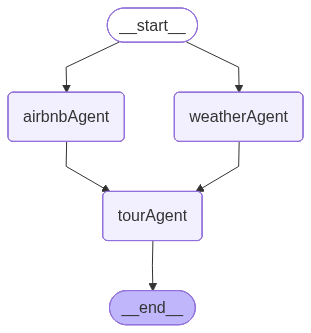

In [26]:
workflow = graph.compile()

Image(workflow.get_graph().draw_mermaid_png())

In [27]:
async for step in workflow.astream({"topic": "Find me the top 5 Airbnb in Goa for next 3 days within 8000 for 2 people ?"}):
    print(step)

display(Markdown(f"{step['tourAgent']['summary']}\n"))

Weather Agent..
Initializing connection...


/var/folders/xt/q4j7gg3n3z3fx6rz7xq8hxfc0000gn/T/ipykernel_36704/2406205257.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  weather_agent = create_react_agent(


WeatherForecast tool
Loading tools...


/var/folders/xt/q4j7gg3n3z3fx6rz7xq8hxfc0000gn/T/ipykernel_36704/3637644559.py:23: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


{'weatherAgent': {'knowledge': ["[Info from Weather Search]\n## Weather Report for Goa (Next 3 Days)\n\n**Current Conditions:** 26.1°C with Clear (Clear)\n\n**Forecast Summary:**\n- **2026-04-11:** Sunny, 29.5°C / 25.6°C (Clear)\n- **2026-04-12:** Sunny, 29.8°C / 25.0°C (Clear)\n- **2026-04-13:** Sunny, 30.2°C / 25.9°C (Clear)\n\n**Tour Recommendation:**  \nBased on the weather forecast, it is an excellent time to visit Goa. The weather will be consistently sunny and warm with temperatures ranging from 25-30°C. Pack light summer clothing, sunscreen, and sunglasses. Perfect weather for beach activities, water sports, and outdoor exploration. Consider staying hydrated and booking beach shacks or poolside accommodations to beat the heat during peak afternoon hours.\n\n---\n\nRegarding Airbnb accommodations in Goa within ₹8000 for 2 people, I'd recommend checking:\n- Airbnb's website or app directly\n- Popular areas like Calangute, Baga, Anjuna, or Palolem\n- Filter by price range (₹0-8000

  + Exception Group Traceback (most recent call last):
  |   File "/Users/sushovansaha/Desktop/Project/Personal/Streamlit-AI-Portfolio/.port/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3745, in run_code
  |     await eval(code_obj, self.user_global_ns, self.user_ns)
  |   File "/var/folders/xt/q4j7gg3n3z3fx6rz7xq8hxfc0000gn/T/ipykernel_36704/2952942410.py", line 1, in <module>
  |     async for step in workflow.astream({"topic": "Find me the top 5 Airbnb in Goa for next 3 days within 8000 for 2 people ?"}):
  |   File "/Users/sushovansaha/Desktop/Project/Personal/Streamlit-AI-Portfolio/.port/lib/python3.12/site-packages/langgraph/pregel/main.py", line 3128, in astream
  |     async for _ in runner.atick(
  |   File "/Users/sushovansaha/Desktop/Project/Personal/Streamlit-AI-Portfolio/.port/lib/python3.12/site-packages/langgraph/pregel/_runner.py", line 410, in atick
  |     _panic_or_proceed(
  |   File "/Users/sushovansaha/Desktop/Project/Personal/Streamlit-AI-